In [1]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
X = np.arange(100).reshape(-1, 1)
y = np.random.normal(65, 3, 100)
y[55] = 92

x is time, y is temprature

In [3]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [4]:
print(model.coef_)
print(model.intercept_)

[-0.01228828]
65.81153589301891


y=kx+b coef:k  intercept:b

In [5]:
y_pred = model.predict(X)

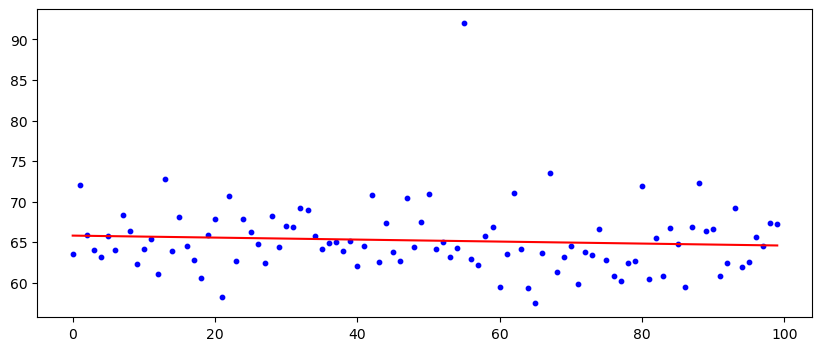

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
axes.scatter(X, y, color="blue", s=10)
axes.plot(X, y_pred, color="red")
plt.show()

In [7]:
y = y + X.flatten() * 0.1

This means that the temperature rises by 0.1 degrees for every unit of time that passes.

In [8]:
print(model.coef_)
print(model.intercept_)

[-0.01228828]
65.81153589301891


In [9]:
from sklearn.metrics import r2_score
print(r2_score(y, y_pred))

-1.0789614627475337


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

test_size=0.2 = 20% of the data is used for testing, and 80% for training.
random_state=42 = Fixed random seed; 42 is commonly used in machine learning.

In [11]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred_test = model2.predict(X_test)
print(r2_score(y_test, y_pred_test))

0.38278999028755134


In [12]:
print(55 in X_test)

False


In [13]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(r2_score(y_test, y_pred_rf))

0.05126269035772413


In [14]:
print("Linear Regression R²:", r2_score(y_test, y_pred_test))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Linear Regression R²: 0.38278999028755134
Random Forest R²: 0.05126269035772413


In [15]:
import pandas as pd
np.random.seed(42)
df2 = pd.DataFrame({
    "pressure": np.random.normal(100, 5, 100),
    "temp": np.random.normal(65, 3, 100),
    "vibration": np.random.normal(0.5, 0.1, 100)
})
df2.loc[30, "pressure"] = 145
df2.loc[55, "temp"] = 92
df2.loc[78, "vibration"] = 1.8

y2 = df2["temp"] + np.random.normal(0, 1, 100)

In [16]:
X2 = df2[["pressure", "temp", "vibration"]]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf2.fit(X2_train, y2_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
importances = model_rf2.feature_importances_
for name, importance in zip(X2.columns, importances):
    print(f"{name}: {importance:.3f}")

pressure: 0.027
temp: 0.959
vibration: 0.014


zip: let the name and its own importances be matched
loop through each pair of (feature name, importance value)